# Retail Flow Analysis

Explore which market, product and client conditions are associated with higher secondary-market sell activity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

positions = pd.read_csv("../data/synthetic_retail_flow_dataset.csv")   

positions.head()

,snapshot_id,timestamp,position_id,client,product_id,product_type,underlyings,worst_underlying,notional,issue_date,...,autocall_pct,autocall_distance,return_1d,return_5d,shock_magnitude,iv_change,client_pnl_pct,historical_client_sell_rate,recent_client_activity,sold_next_24h
0,S000001,2026-01-05 09:00:00,POS0001,Client_01,P024,Barrier Reverse Convertible,UBS,UBS,100000,2025-09-21,...,NaN,NaN,-0.011313,NaN,0.011313,0.017108,-0.009854,0.090909,2,0
1,S000002,2026-01-05 09:00:00,POS0002,Client_01,P028,Reverse Convertible,MSFT,MSFT,2000000,2025-10-16,...,NaN,NaN,-0.012231,NaN,0.012231,-0.001225,0.028557,0.090909,2,0
2,S000003,2026-01-05 09:00:00,POS0003,Client_01,P004,Callable Multi BRC,UBS|NESN|NOVN,UBS,500000,2025-07-02,...,1.0,-0.263063,-0.011313,NaN,0.011313,0.017108,-0.124650,0.090909,2,0
3,S000004,2026-01-05 09:00:00,POS0004,Client_01,P011,Callable Multi BRC,SMI|NOVN|ROG,SMI,750000,2025-07-30,...,1.0,0.001263,0.004958,NaN,0.004958,-0.015980,0.011449,0.090909,2,0
4,S000005,2026-01-05 09:00:00,POS0005,Client_01,P020,Barrier Reverse Convertible,AAPL,AAPL,250000,2025-08-21,...,NaN,NaN,-0.047460,NaN,0.047460,0.030727,-0.092173,0.090909,2,0


In [2]:
positions["sold_next_24h"].value_counts(normalize=True)

sold_next_24h
0    0.968736
1    0.031264
Name: proportion, dtype: float64

## Market shock buckets

Group daily market moves into simple shock ranges to compare sell behaviour under different market conditions.

In [3]:
positions["shock_bucket"] = pd.cut(
    positions["shock_magnitude"],
    bins=[0, 0.05, 0.10, float("inf")],
    labels=["0-5%", "5-10%", ">10%"],
    include_lowest=True
)
positions["shock_bucket"].value_counts().sort_index()


shock_bucket
0-5%     6243
5-10%     359
>10%      115
Name: count, dtype: int64

In [4]:
shock_sell_rate = positions.groupby("shock_bucket")["sold_next_24h"].mean()

shock_sell_rate

shock_bucket
0-5%     0.025469
5-10%    0.064067
>10%     0.243478
Name: sold_next_24h, dtype: float64

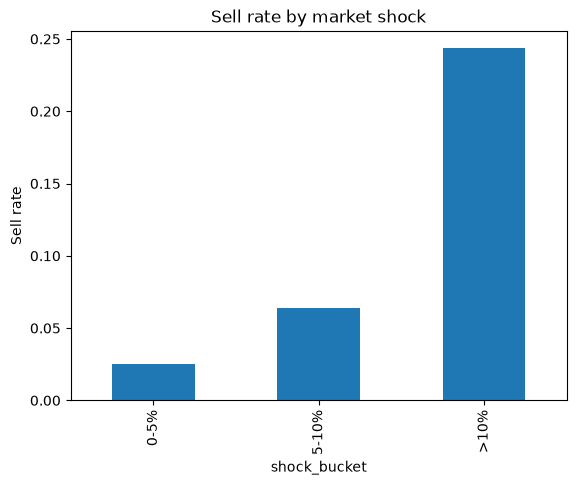

In [5]:
shock_sell_rate.plot(
    kind="bar",
    ylabel="Sell rate",
    title="Sell rate by market shock"
)

plt.show()

Sell activity increases during larger market moves, with the strongest increase during shocks above 10%.

## Barrier proximity

Compare sell activity depending on how close the product is to its barrier.

In [6]:
positions["barrier_bucket"] = pd.cut(
    positions["barrier_distance"],
    bins=[-float("inf"), 0, 0.05, 0.10, 0.20, float("inf")],
    labels=["Below barrier", "0-5%", "5-10%", "10-20%", ">20%"]
)

In [7]:
barrier_sell_rate = (
    positions.groupby("barrier_bucket")["sold_next_24h"].mean()
    )
barrier_sell_rate

barrier_bucket
Below barrier    0.205128
0-5%             0.109677
5-10%            0.050847
10-20%           0.054889
>20%             0.022986
Name: sold_next_24h, dtype: float64

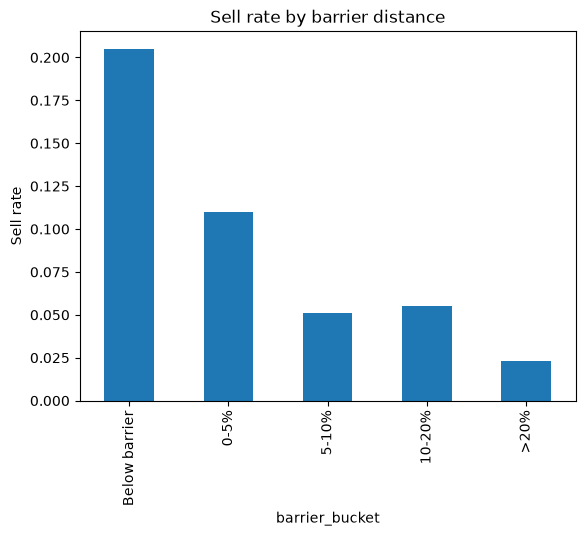

In [8]:
barrier_sell_rate.plot(
    kind="bar",
    ylabel = "Sell rate",
    title ="Sell rate by barrier distance"
)
plt.show()

Sell activity increases as products move closer to or below their barrier level.

## Shock and barrier interaction

Combine market shock magnitude and barrier proximity to identify conditions with the highest sell activity.

In [9]:
shock_barrier = positions.pivot_table(
    index = "barrier_bucket",
    columns="shock_bucket",
    values="sold_next_24h",
    aggfunc="mean"
)
shock_barrier

shock_bucket,0-5%,5-10%,>10%
barrier_bucket,,,
Below barrier,0.163636,0.300000,0.333333
0-5%,0.079137,0.285714,0.444444
5-10%,0.032558,0.166667,0.333333
10-20%,0.036364,0.285714,0.421053
>20%,0.020702,0.030888,0.137931


In [10]:
shock_barrier_count = positions.pivot_table(
    index="barrier_bucket",
    columns="shock_bucket",
    values="sold_next_24h",
    aggfunc="count"
)

shock_barrier_count

shock_bucket,0-5%,5-10%,>10%
barrier_bucket,,,
Below barrier,55,20,3
0-5%,139,7,9
5-10%,215,12,9
10-20%,550,14,19
>20%,3816,259,58


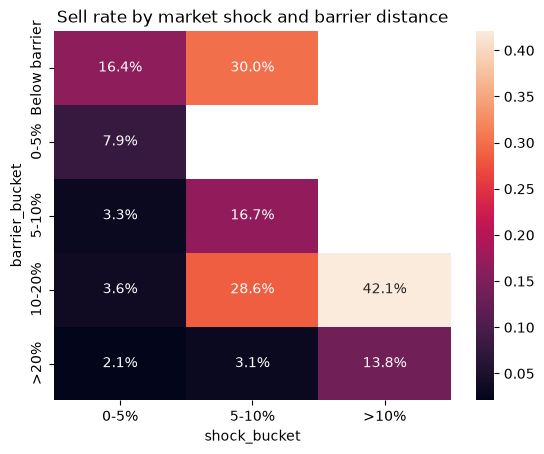

In [11]:
sns.heatmap(
    shock_barrier,
    annot=True,
    fmt=".1%",
    mask=shock_barrier_count < 10
)

plt.title("Sell rate by market shock and barrier distance")
plt.show()

Large market shocks and barrier proximity reinforce each other, with higher sell activity when both market stress and product-specific downside risk are elevated.

Cells with fewer than 10 observations are omitted.

## Client P&L

Compare sell activity across different client profit and loss levels.

In a real trading setup, client P&L could be derived from the client's purchase price, current product valuation and cashflows already received.

In [12]:
positions["pnl_bucket"] = pd.cut(
    positions["client_pnl_pct"],
    bins=[-float("inf"), -0.20, -0.10, 0, 0.10, float("inf")],
    labels=["<-20%", "-20% to -10%", "-10% to 0%", "0% to 10%", ">10%"]
)

pnl_sell_rate = (
    positions
    .groupby("pnl_bucket", observed=True)["sold_next_24h"]
    .mean()
)

pnl_sell_rate

pnl_bucket
<-20%           0.144578
-20% to -10%    0.041522
-10% to 0%      0.030812
0% to 10%       0.013562
>10%            0.018081
Name: sold_next_24h, dtype: float64

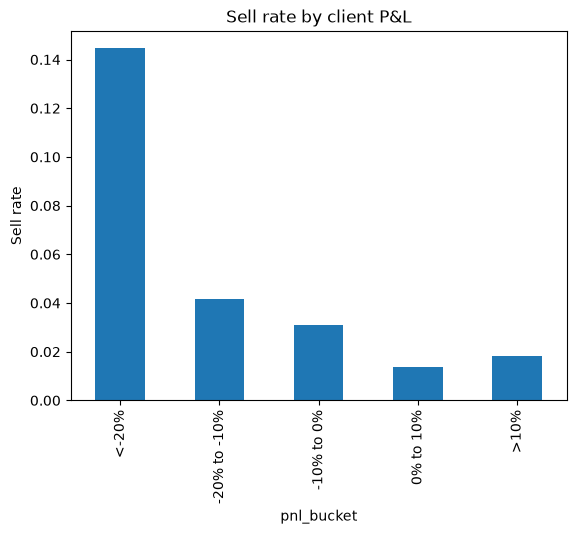

In [13]:
pnl_sell_rate.plot(
    kind="bar",
    ylabel="Sell rate",
    title="Sell rate by client P&L"
)

plt.show()

## Product type

In [14]:
product_sell_rate = (
    positions
    .groupby("product_type")["sold_next_24h"]
    .mean()
    .sort_values(ascending=False)
)

product_sell_rate

product_type
Callable Multi BRC             0.042627
Autocall                       0.031879
Reverse Convertible            0.027851
Barrier Reverse Convertible    0.026802
Bonus Certificate              0.025952
Tracker                        0.021851
Name: sold_next_24h, dtype: float64

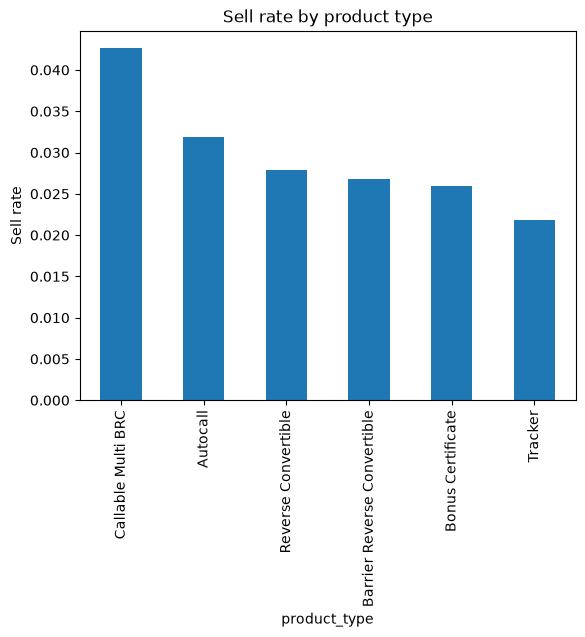

In [15]:
product_sell_rate.plot(
    kind="bar",
    ylabel="Sell rate",
    title="Sell rate by product type"
)

plt.show()

Callable Multi BRCs show the highest sell rate in the synthetic sample, although differences across product types are smaller than those observed for market shocks, barrier proximity or client P&L.

## PnL and Barrier Distance

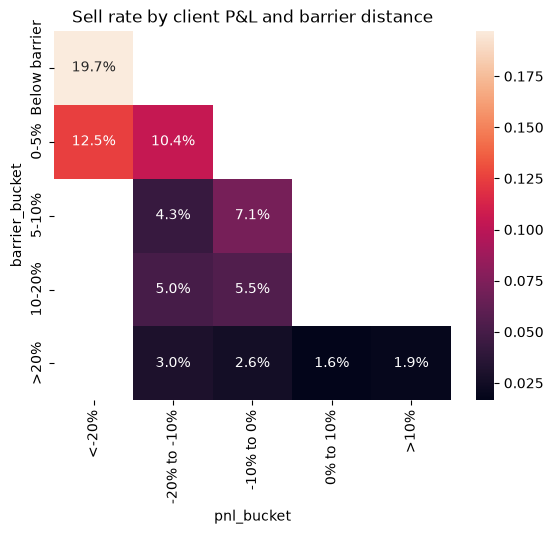

In [16]:
pnl_barrier = positions.pivot_table(
    index="barrier_bucket",
    columns="pnl_bucket",
    values="sold_next_24h",
    aggfunc="mean"
)

pnl_barrier_count = positions.pivot_table(
    index="barrier_bucket",
    columns="pnl_bucket",
    values="sold_next_24h",
    aggfunc="count"
)

sns.heatmap(
    pnl_barrier,
    annot=True,
    fmt=".1%",
    mask=pnl_barrier_count < 10
)

plt.title("Sell rate by client P&L and barrier distance")
plt.show()

Sell activity is highest when client losses are combined with barrier proximity, suggesting that product risk and client P&L can reinforce each other as drivers of secondary-market flow.

## Observation proximity and autocall distance

In [17]:
positions["observation_bucket"] = pd.cut(
    positions["days_to_observation"],
    bins=[0, 7, 30],
    labels=["0-7 days", "8-30 days"],
    include_lowest=True
)

positions["autocall_bucket"] = pd.cut(
    positions["autocall_distance"],
    bins=[-float("inf"), -0.10, -0.05, 0, float("inf")],
    labels=[
        ">10% below",
        "5-10% below",
        "0-5% below",
        "At/above"
    ]
)

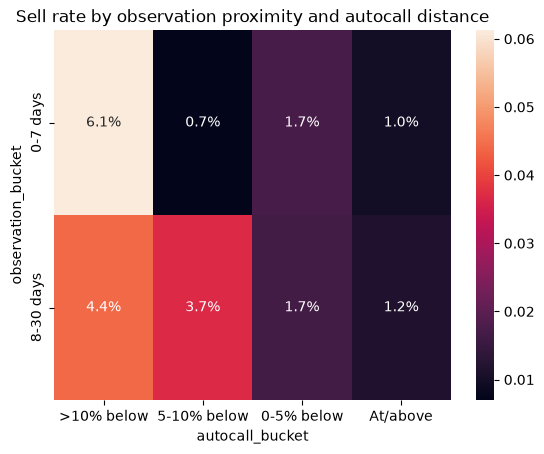

In [18]:
observation_autocall = positions.pivot_table(
    index="observation_bucket",
    columns="autocall_bucket",
    values="sold_next_24h",
    aggfunc="mean"
)

observation_autocall_count = positions.pivot_table(
    index="observation_bucket",
    columns="autocall_bucket",
    values="sold_next_24h",
    aggfunc="count"
)

sns.heatmap(
    observation_autocall,
    annot=True,
    fmt=".1%",
    mask=observation_autocall_count < 10
)

plt.title("Sell rate by observation proximity and autocall distance")
plt.show()

In the synthetic sample, sell activity is higher when an observation date is close and the product remains well below its autocall level. Products near or above the autocall level show lower sell activity.

## Key observations

Sell activity in the synthetic dataset is most strongly associated with large market shocks, barrier proximity and negative client P&L.

The interaction analysis shows that these factors can reinforce each other. For autocallable products, observation timing also matters together with the distance to the autocall level.

These patterns motivate combining market conditions, product state and client behaviour in the sell-probability model.